# Libraries

In [1]:
%run ../../../setup_workspace.py # ../ means level up 

In [150]:
from matplotlib.ticker import ScalarFormatter

# SC5732

In [182]:
def power(x, k, b):
    return b * x ** k
    
def K(q, I, z):
    return np.trapezoid(I[:, None] * np.cos(q[:, None] * z[None, :]), q, axis=0)

def calibrate(q, I_array, q_left, q_right):
    mask = (q > q_left) * (q < q_right)

    res = I_array

    for i in range(len(res)):
        res[i] /= np.mean(np.trapezoid(res[i][mask], q[mask])) 

    return res

def SAXS_plot(w,h):
    font = {'family': 'serif',
        'color':  'black',
        'weight': 'normal',
        'size': 20,
        }
    
    fig, ax = plt.subplots(figsize=(w,h))
    ax.set_position([0.15, 0.15, 0.7, 0.7])
    
    plt.semilogx()
    plt.semilogy()

    plt.xlabel('q (nm⁻¹)', fontdict = font)
    plt.ylabel('I (a.u.)', fontdict = font)

    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)

    #ax.get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.tick_params(axis="both",which='both',direction="in", width=3, length=3)
    #ax.minorticks_off()

    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(2)
    ax.set_xticks([0.2, 1])
    ax.xaxis.set_major_formatter(ScalarFormatter())
    

In [100]:
poni = r"E:\PEG_g_PLA Nikos 2025\Nicos_mask\SAXS_12p8keV_2m_SAXS-WAXS_LDSC.poni"
ai = pyFAI.load(poni)

In [101]:
mask = r"E:\PEG_g_PLA Nikos 2025\Nicos_mask\SelfmadeMASK_SAXS.edf"
file_mask = mask
img_mask = fabio.open(mask).data

# Analysis

### 317

In [247]:
path = r"E:\PEG_g_PLA Nikos 2025\SC5732\Brushes_PEG_PLA\Brushes_PEG_PLA_PA317_98_2_800DP_firstheat_175C_and_back"
Exp = BM26_experiment(path)
T = Exp.get_T_profile()

q, I_array = Exp.integrate1d_SAXS(ai, 1000, mask=img_mask, unit='q_nm^-1')

T = Exp.get_T_profile()
px.scatter(x = range(len(T)), y = T)

I_calib = calibrate(q, I_array, 5, 6)

Found 304 EDF files in SAXS
Found 304 EDF files in SAXS


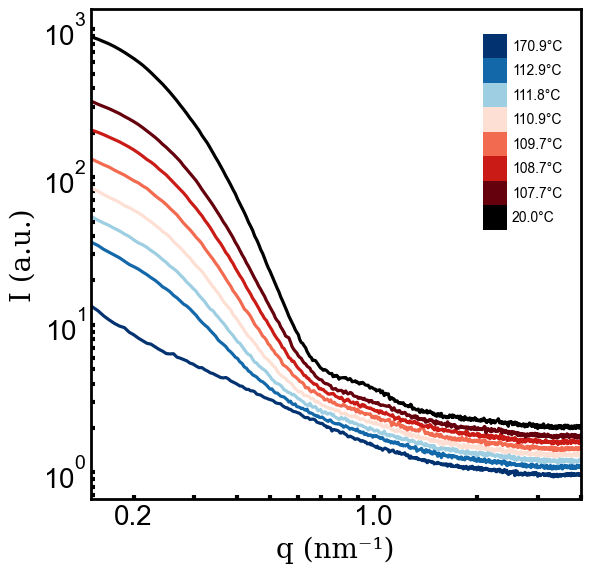

In [248]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Настройка шрифта Arial для всего графика
plt.rcParams['font.family'] = 'Arial'

SAXS_plot(7,7)

colors = ['#033270', '#1368AA', '#9DCEE2', '#FEDFD4', '#F26A4F', '#CB1B16', '#65010C', 'black']
indexes = [150, 205, 206, 207, 208, 209, 210, 300]

k = 0
ampl = 1.1
for i in indexes:
    plt.plot(q, I_calib[i] * ampl ** k, color=colors[k], linewidth=2.3)  # линии толще
    k += 1

plt.xlim(0.15, 4)

# Легенда с квадратиками вплотную
x0, y0 = 0.8, 0.9
size = 0.05  # размер стороны квадрата
dy = size    # расстояние = размеру квадрата (ноль зазора)

for k, i in enumerate(indexes):
    rect = Rectangle((x0, y0 - k*dy), size, size, 
                     facecolor=colors[k], edgecolor='none',
                     transform=plt.gca().transAxes)
    plt.gca().add_patch(rect)
    plt.text(x0 + size + 0.01, y0 - k*dy + size/2, f'{T[i]}°C',
            transform=plt.gca().transAxes, fontsize=10, va='center',
            fontfamily='Arial')
plt.savefig(r'C:\Users\LabPCA\Desktop\PEG_PLA\Nikos317.png', dpi=300, bbox_inches='tight', transparent=True)

### 314

In [249]:
path = r'E:\PEG_g_PLA Nikos 2025\SC5732\Brushes_PEG_PLA\Brushes_PEG_PLA_PA316_98_2_600DP_firstheat_180C_and_back'

Exp = BM26_experiment(path)
T = Exp.get_T_profile()

q, I_array = Exp.integrate1d_SAXS(ai, 1000, mask=img_mask, unit='q_nm^-1')

T = Exp.get_T_profile()
px.scatter(x = range(len(T)), y = T)

I_calib = calibrate(q, I_array, 5, 6)

Found 313 EDF files in SAXS
Found 313 EDF files in SAXS


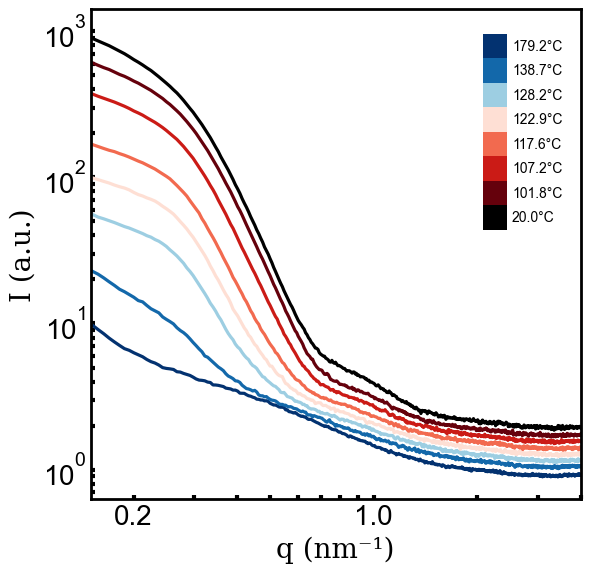

In [250]:
plt.rcParams['font.family'] = 'Arial'

SAXS_plot(7,7)

colors = ['#033270', '#1368AA', '#9DCEE2', '#FEDFD4', '#F26A4F', '#CB1B16', '#65010C', 'black']
indexes = [150, 190, 200, 205, 210, 220, 225, 311]

k = 0
ampl = 1.1
for i in indexes:
    plt.plot(q, I_calib[i] * ampl ** k, color=colors[k], linewidth=2.3)  # линии толще
    k += 1

plt.xlim(0.15, 4)

# Легенда с квадратиками вплотную
x0, y0 = 0.8, 0.9
size = 0.05  # размер стороны квадрата
dy = size    # расстояние = размеру квадрата (ноль зазора)

for k, i in enumerate(indexes):
    rect = Rectangle((x0, y0 - k*dy), size, size, 
                     facecolor=colors[k], edgecolor='none',
                     transform=plt.gca().transAxes)
    plt.gca().add_patch(rect)
    plt.text(x0 + size + 0.01, y0 - k*dy + size/2, f'{T[i]}°C',
            transform=plt.gca().transAxes, fontsize=10, va='center',
            fontfamily='Arial')
plt.savefig(r'C:\Users\LabPCA\Desktop\PEG_PLA\Nikos316.png', dpi=300, bbox_inches='tight', transparent=True)

### 314

Found 350 EDF files in SAXS
Found 350 EDF files in SAXS


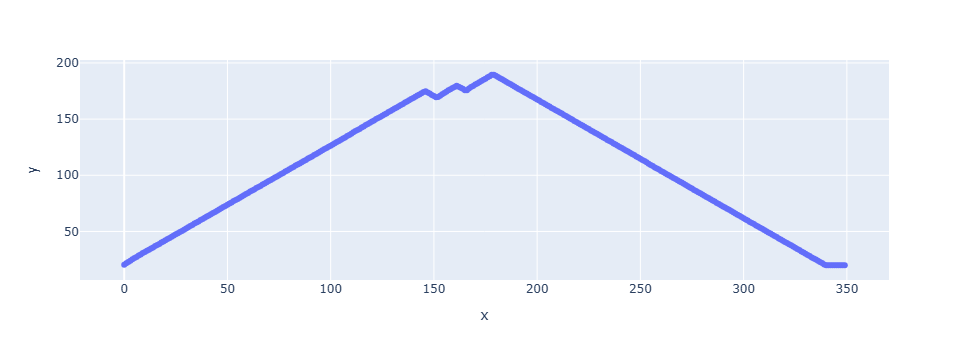

In [251]:
path = r"E:\PEG_g_PLA Nikos 2025\SC5732\Brushes_PEG_PLA\Brushes_PEG_PLA_PA314_97p5_2p5_600DP_firstheat_175C_and_back"

Exp = BM26_experiment(path)
T = Exp.get_T_profile()

q, I_array = Exp.integrate1d_SAXS(ai, 1000, mask=img_mask, unit='q_nm^-1')

T = Exp.get_T_profile()
# px.scatter(x = range(len(T)), y = T)

I_calib = calibrate(q, I_array, 5, 6)
px.scatter(x = range(len(T)), y = T)


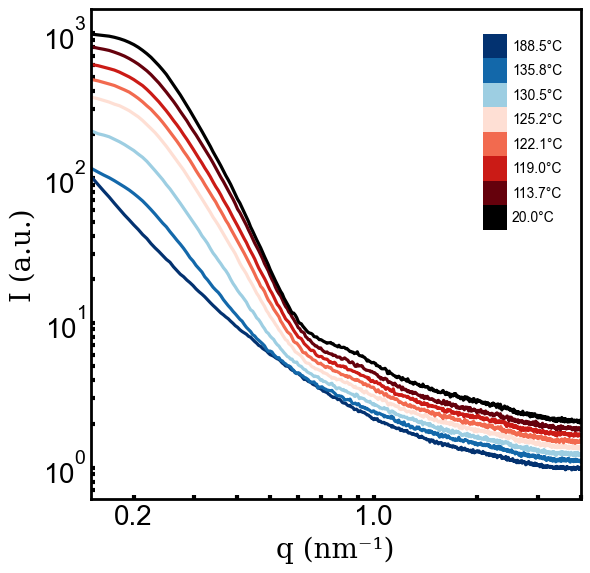

In [252]:
plt.rcParams['font.family'] = 'Arial'

SAXS_plot(7,7)

colors = ['#033270', '#1368AA', '#9DCEE2', '#FEDFD4', '#F26A4F', '#CB1B16', '#65010C', 'black']
indexes = [180, 230, 235, 240, 243, 246, 251, 348]

k = 0
ampl = 1.1
for i in indexes:
    plt.plot(q, I_calib[i] * ampl ** k, color=colors[k], linewidth=2.3)  # линии толще
    k += 1

plt.xlim(0.15, 4)

# Легенда с квадратиками вплотную
x0, y0 = 0.8, 0.9
size = 0.05  # размер стороны квадрата
dy = size    # расстояние = размеру квадрата (ноль зазора)

for k, i in enumerate(indexes):
    rect = Rectangle((x0, y0 - k*dy), size, size, 
                     facecolor=colors[k], edgecolor='none',
                     transform=plt.gca().transAxes)
    plt.gca().add_patch(rect)
    plt.text(x0 + size + 0.01, y0 - k*dy + size/2, f'{T[i]}°C',
            transform=plt.gca().transAxes, fontsize=10, va='center',
            fontfamily='Arial')
plt.savefig(r'C:\Users\LabPCA\Desktop\PEG_PLA\Nikos314.png', dpi=300, bbox_inches='tight', transparent=True)

### 310

Found 303 EDF files in SAXS
Found 303 EDF files in SAXS


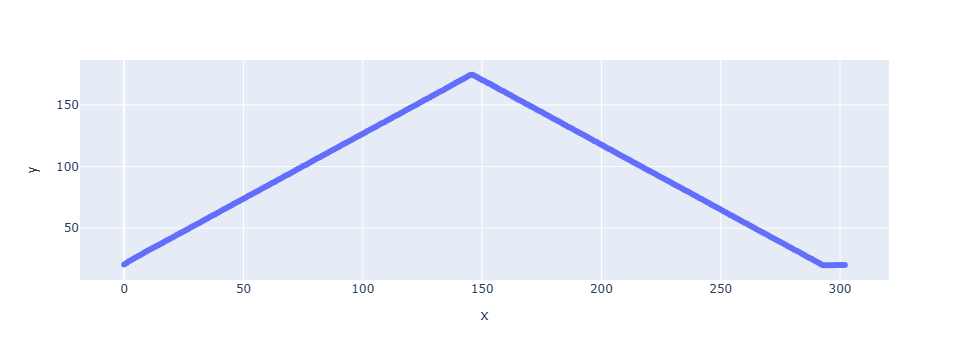

In [253]:
path = r"E:\PEG_g_PLA Nikos 2025\SC5732\Brushes_PEG_PLA\Brushes_PEG_PLA_PA310_98_2_800DP_firstheat_175C_and_back"

Exp = BM26_experiment(path)
T = Exp.get_T_profile()

q, I_array = Exp.integrate1d_SAXS(ai, 1000, mask=img_mask, unit='q_nm^-1')

T = Exp.get_T_profile()
# px.scatter(x = range(len(T)), y = T)

I_calib = calibrate(q, I_array, 5, 6)
px.scatter(x = range(len(T)), y = T)


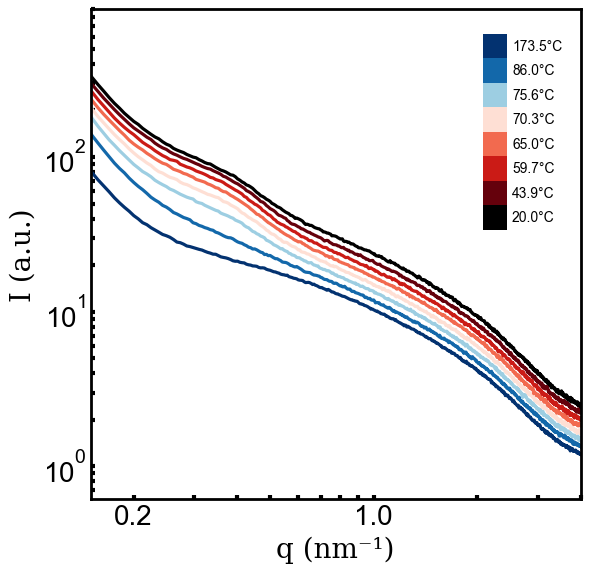

In [254]:
plt.rcParams['font.family'] = 'Arial'

SAXS_plot(7,7)

colors = ['#033270', '#1368AA', '#9DCEE2', '#FEDFD4', '#F26A4F', '#CB1B16', '#65010C', 'black']
indexes = [147, 230, 240, 245, 250, 255, 270, 302]

k = 0
ampl = 1.1
for i in indexes:
    plt.plot(q, I_calib[i] * ampl ** k, color=colors[k], linewidth=2.3)  # линии толще
    k += 1

plt.xlim(0.15, 4)

# Легенда с квадратиками вплотную
x0, y0 = 0.8, 0.9
size = 0.05  # размер стороны квадрата
dy = size    # расстояние = размеру квадрата (ноль зазора)

for k, i in enumerate(indexes):
    rect = Rectangle((x0, y0 - k*dy), size, size, 
                     facecolor=colors[k], edgecolor='none',
                     transform=plt.gca().transAxes)
    plt.gca().add_patch(rect)
    plt.text(x0 + size + 0.01, y0 - k*dy + size/2, f'{T[i]}°C',
            transform=plt.gca().transAxes, fontsize=10, va='center',
            fontfamily='Arial')
plt.savefig(r'C:\Users\LabPCA\Desktop\PEG_PLA\Nikos310.png', dpi=300, bbox_inches='tight', transparent=True)

### 309

Found 304 EDF files in SAXS
Found 304 EDF files in SAXS


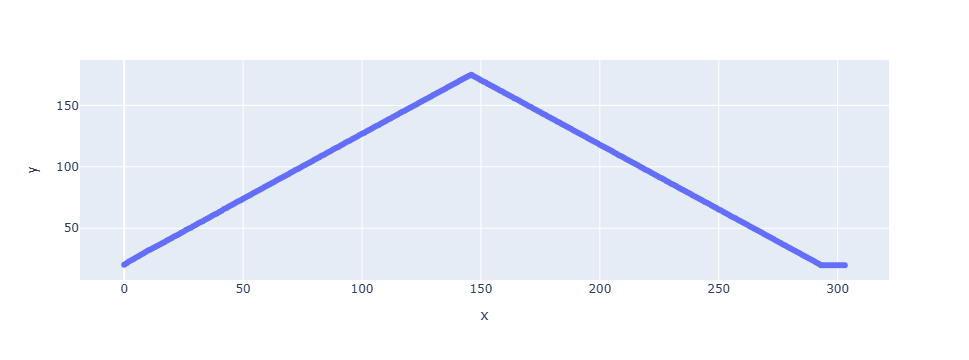

In [255]:
path = r"E:\PEG_g_PLA Nikos 2025\SC5732\Brushes_PEG_PLA\Brushes_PEG_PLA_PA309_97p5_2p5_800DP_firstheat_175C_and_back"

Exp = BM26_experiment(path)
T = Exp.get_T_profile()

q, I_array = Exp.integrate1d_SAXS(ai, 1000, mask=img_mask, unit='q_nm^-1')

T = Exp.get_T_profile()
# px.scatter(x = range(len(T)), y = T)

I_calib = calibrate(q, I_array, 5, 6)
px.scatter(x = range(len(T)), y = T)



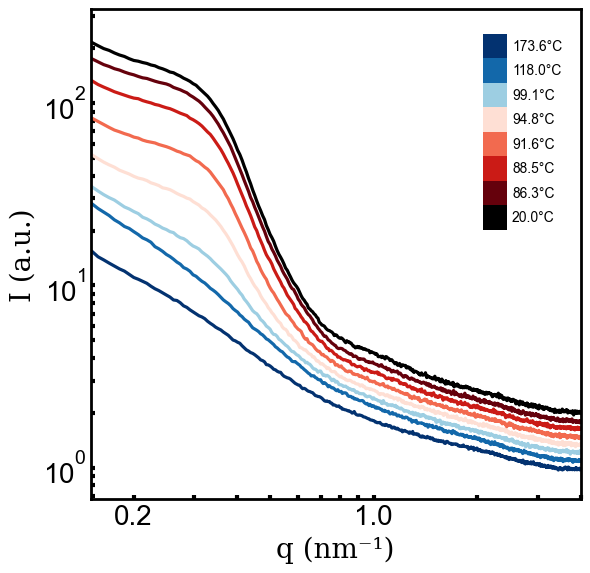

In [259]:
plt.rcParams['font.family'] = 'Arial'

SAXS_plot(7,7)

colors = ['#033270', '#1368AA', '#9DCEE2', '#FEDFD4', '#F26A4F', '#CB1B16', '#65010C', 'black']
indexes = [147, 200, 218, 222, 225, 228, 230, 302]

k = 0
ampl = 1.1
for i in indexes:
    plt.plot(q, I_calib[i] * ampl ** k, color=colors[k], linewidth=2.3)  # линии толще
    k += 1

plt.xlim(0.15, 4)

# Легенда с квадратиками вплотную
x0, y0 = 0.8, 0.9
size = 0.05  # размер стороны квадрата
dy = size    # расстояние = размеру квадрата (ноль зазора)

for k, i in enumerate(indexes):
    rect = Rectangle((x0, y0 - k*dy), size, size, 
                     facecolor=colors[k], edgecolor='none',
                     transform=plt.gca().transAxes)
    plt.gca().add_patch(rect)
    plt.text(x0 + size + 0.01, y0 - k*dy + size/2, f'{T[i]}°C',
            transform=plt.gca().transAxes, fontsize=10, va='center',
            fontfamily='Arial')
plt.savefig(r'C:\Users\LabPCA\Desktop\PEG_PLA\Nikos309.png', dpi=300, bbox_inches='tight', transparent=True)

### 308

Found 313 EDF files in SAXS
Found 313 EDF files in SAXS


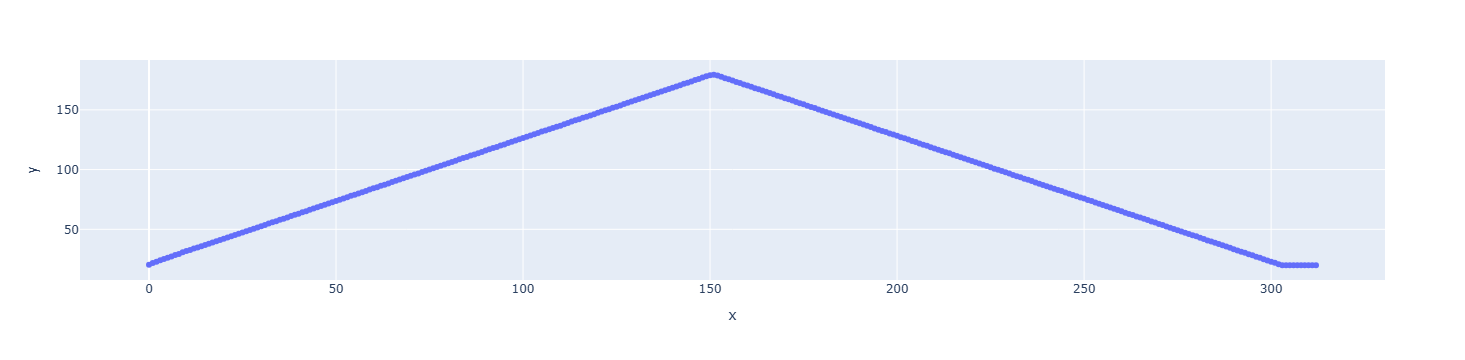

In [285]:
path = r'E:\PEG_g_PLA Nikos 2025\SC5732\Brushes_PEG_PLA\Brushes_PEG_PLA_PA308_98_2_600DP_firstheat_180C_and_back'

Exp = BM26_experiment(path)
T = Exp.get_T_profile()

q, I_array = Exp.integrate1d_SAXS(ai, 1000, mask=img_mask, unit='q_nm^-1')

T = Exp.get_T_profile()
# px.scatter(x = range(len(T)), y = T)

I_calib = calibrate(q, I_array, 3, 4)
px.scatter(x = range(len(T)), y = T)




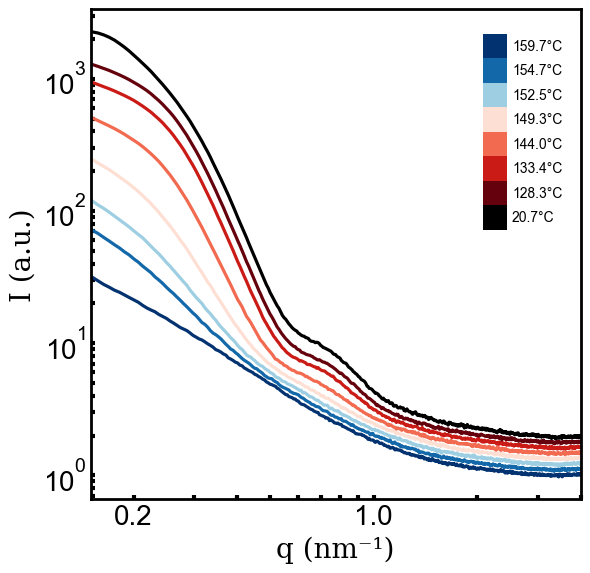

In [295]:
plt.rcParams['font.family'] = 'Arial'

SAXS_plot(7,7)

colors = ['#033270', '#1368AA', '#9DCEE2', '#FEDFD4', '#F26A4F', '#CB1B16', '#65010C', 'black']
indexes = [170, 175, 177, 180, 185, 195, 200, 302]

k = 0
ampl = 1.1
for i in indexes:
    plt.plot(q, I_calib[i] * ampl ** k, color=colors[k], linewidth=2.3)  # линии толще
    k += 1

plt.xlim(0.15, 4)

# Легенда с квадратиками вплотную
x0, y0 = 0.8, 0.9
size = 0.05  # размер стороны квадрата
dy = size    # расстояние = размеру квадрата (ноль зазора)

for k, i in enumerate(indexes):
    rect = Rectangle((x0, y0 - k*dy), size, size, 
                     facecolor=colors[k], edgecolor='none',
                     transform=plt.gca().transAxes)
    plt.gca().add_patch(rect)
    plt.text(x0 + size + 0.01, y0 - k*dy + size/2, f'{T[i]}°C',
            transform=plt.gca().transAxes, fontsize=10, va='center',
            fontfamily='Arial')
plt.savefig(r'C:\Users\LabPCA\Desktop\PEG_PLA\Nikos308.png', dpi=300, bbox_inches='tight', transparent=True)

### 304

Found 304 EDF files in SAXS
Found 304 EDF files in SAXS


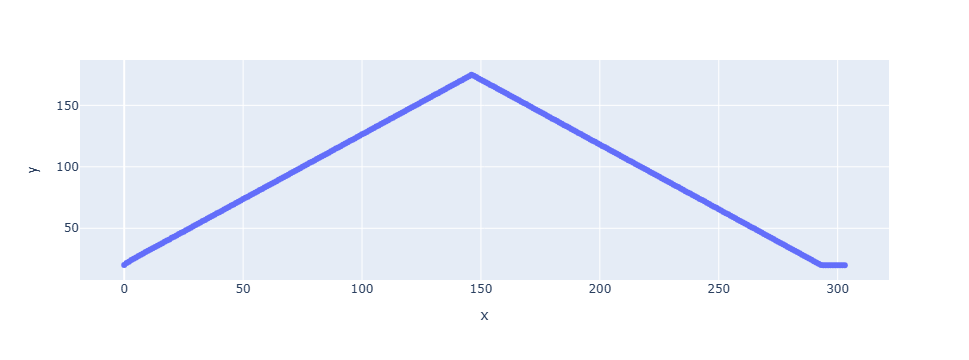

In [263]:
path = r'E:\PEG_g_PLA Nikos 2025\SC5732\Brushes_PEG_PLA\Brushes_PEG_PLA_PA304_97_3_600DP_firstheat_175C_and_back'
Exp = BM26_experiment(path)
T = Exp.get_T_profile()

q, I_array = Exp.integrate1d_SAXS(ai, 1000, mask=img_mask, unit='q_nm^-1')

T = Exp.get_T_profile()
# px.scatter(x = range(len(T)), y = T)

I_calib = calibrate(q, I_array, 5, 6)
px.scatter(x = range(len(T)), y = T)




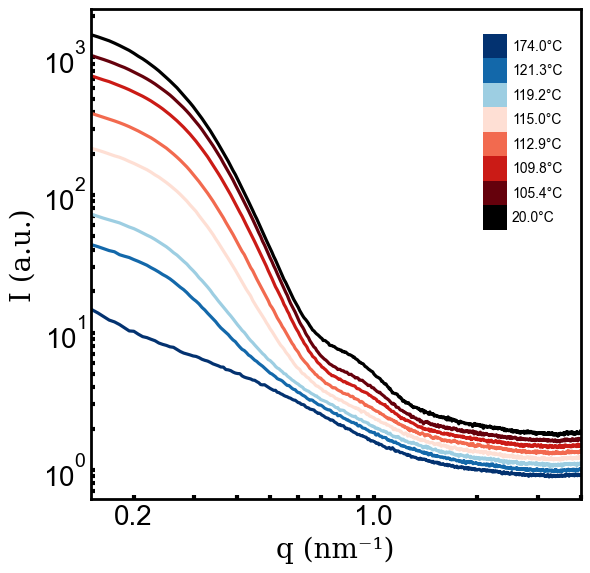

In [264]:
plt.rcParams['font.family'] = 'Arial'

SAXS_plot(7,7)

colors = ['#033270', '#1368AA', '#9DCEE2', '#FEDFD4', '#F26A4F', '#CB1B16', '#65010C', 'black']
indexes = [147, 197, 199, 203, 205, 208, 212, 302]

k = 0
ampl = 1.1
for i in indexes:
    plt.plot(q, I_calib[i] * ampl ** k, color=colors[k], linewidth=2.3)  # линии толще
    k += 1

plt.xlim(0.15, 4)

# Легенда с квадратиками вплотную
x0, y0 = 0.8, 0.9
size = 0.05  # размер стороны квадрата
dy = size    # расстояние = размеру квадрата (ноль зазора)

for k, i in enumerate(indexes):
    rect = Rectangle((x0, y0 - k*dy), size, size, 
                     facecolor=colors[k], edgecolor='none',
                     transform=plt.gca().transAxes)
    plt.gca().add_patch(rect)
    plt.text(x0 + size + 0.01, y0 - k*dy + size/2, f'{T[i]}°C',
            transform=plt.gca().transAxes, fontsize=10, va='center',
            fontfamily='Arial')
plt.savefig(r'C:\Users\LabPCA\Desktop\PEG_PLA\Nikos304.png', dpi=300, bbox_inches='tight', transparent=True)

### After Heating

In [267]:
def average(I_array, indexes):
    res = np.zeros(len(I_array[0]))
    for i in indexes:
        res += I_array[i]
    return res

In [301]:
# 311
path = r'E:\PEG_g_PLA Nikos 2025\SC5732\Brushes_PEG_PLA\Brushes_PEG_PLA_PA311_ref_600DP_RT'
Exp = BM26_experiment(path)

q, I_array_311 = Exp.integrate1d_SAXS(ai, 1000, mask=img_mask, unit='q_nm^-1')
# plt.plot(q, average(I_array, [i for i in range(-10, 0, 1)]))
print('311')

# 304
path = r"E:\PEG_g_PLA Nikos 2025\SC5732\Brushes_PEG_PLA\Brushes_PEG_PLA_PA304_97_3_600DP_firstheat_175C_and_back"
Exp = BM26_experiment(path)

q, I_array_304 = Exp.integrate1d_SAXS(ai, 1000, mask=img_mask, unit='q_nm^-1')
# plt.plot(q, average(I_array, [i for i in range(-10, 0, 1)]))
print('304')

# 314
path = r"E:\PEG_g_PLA Nikos 2025\SC5732\Brushes_PEG_PLA\Brushes_PEG_PLA_PA314_97p5_2p5_600DP_firstheat_175C_and_back"
Exp = BM26_experiment(path)

q, I_array_314 = Exp.integrate1d_SAXS(ai, 1000, mask=img_mask, unit='q_nm^-1')
# plt.plot(q, average(I_array, [i for i in range(-10, 0, 1)]))
print('314')

# 308
path = r"E:\PEG_g_PLA Nikos 2025\SC5732\Brushes_PEG_PLA\Brushes_PEG_PLA_PA308_98_2_600DP_firstheat_180C_and_back"
Exp = BM26_experiment(path)

q, I_array_308 = Exp.integrate1d_SAXS(ai, 1000, mask=img_mask, unit='q_nm^-1')
# plt.plot(q, average(I_array, [i for i in range(-10, 0, 1)]))
print('308')

# 316
path = r"E:\PEG_g_PLA Nikos 2025\SC5732\Brushes_PEG_PLA\Brushes_PEG_PLA_PA316_98_2_600DP_firstheat_180C_and_back"
Exp = BM26_experiment(path)

q, I_array_316 = Exp.integrate1d_SAXS(ai, 1000, mask=img_mask, unit='q_nm^-1')
# plt.plot(q, average(I_array, [i for i in range(-10, 0, 1)]))
print('316')

311
304
314
308
316


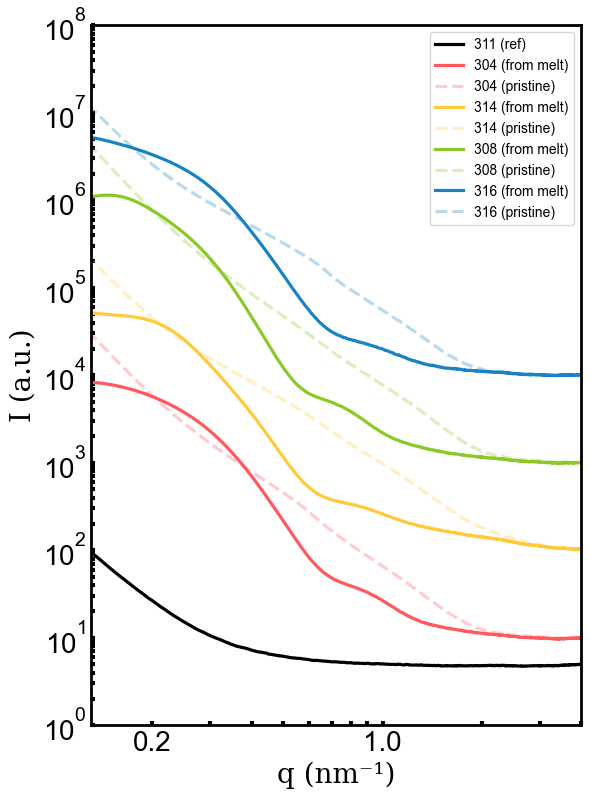

In [341]:
SAXS_plot(7,10)

k = 10

I = average(I_array_311, [i for i in range(-10, 0, 1)]) 
I /= np.mean(I[(q > 4) * (q < 5)])
plt.plot(q, I * 5, linewidth=2.3, color='black', label='311 (ref)' )

# 304
I = average(I_array_304, [i for i in range(-10, 0, 1)]) 
I /= np.mean(I[(q > 4) * (q < 5)])
plt.plot(q, I * k ** 1, linewidth=2.3, color='#ff595e', label='304 (from melt)')

I = average(I_array_304, [i for i in range(0, 10, 1)]) 
I /= np.mean(I[(q > 4) * (q < 5)])
plt.plot(q, I * k ** 1, linewidth=2.3, color='#ff595e', label='304 (pristine)', alpha=0.3, linestyle='--')

# 314
I = average(I_array_314, [i for i in range(-10, 0, 1)]) 
I /= np.mean(I[(q > 4) * (q < 5)])
plt.plot(q, I * k ** 2, linewidth=2.3, color='#ffca3a', label='314 (from melt)')

I = average(I_array_314, [i for i in range(0, 10, 1)]) 
I /= np.mean(I[(q > 4) * (q < 5)])
plt.plot(q, I * k ** 2, linewidth=2.3, color='#ffca3a', label='314 (pristine)', alpha=0.3, linestyle='--')

# 308
I = average(I_array_308, [i for i in range(-10, 0, 1)]) 
I /= np.mean(I[(q > 4) * (q < 5)])
plt.plot(q,I * k ** 3, linewidth=2.3, color='#8ac926', label='308 (from melt)')

I = average(I_array_308, [i for i in range(0, 10, 1)]) 
I /= np.mean(I[(q > 4) * (q < 5)])
plt.plot(q, I * k ** 3, linewidth=2.3, color='#8ac926', label='308 (pristine)', alpha=0.3, linestyle='--')

# 316
I = average(I_array_316, [i for i in range(-10, 0, 1)]) 
I /= np.mean(I[(q > 4) * (q < 5)])
plt.plot(q, I * k ** 4 , linewidth=2.3, color='#1982c4', label='316 (from melt)')

I = average(I_array_316, [i for i in range(0, 10, 1)]) 
I /= np.mean(I[(q > 4) * (q < 5)])
plt.plot(q, I * k ** 4, linewidth=2.3, color='#1982c4', label='316 (pristine)', alpha=0.3, linestyle='--')

plt.legend(fontsize=10, loc=1)
plt.xlim(0.13, 4)
plt.ylim(1e0, 1e8)

plt.savefig(r'C:\Users\LabPCA\Desktop\PEG_PLA\Nikos_311_316.png', dpi=300, bbox_inches='tight', transparent=True)

In [342]:
# 312
path = r"E:\PEG_g_PLA Nikos 2025\SC5732\Brushes_PEG_PLA\Brushes_PEG_PLA_PA311_ref_600DP_RT"
Exp = BM26_experiment(path)

q, I_array_312 = Exp.integrate1d_SAXS(ai, 1000, mask=img_mask, unit='q_nm^-1')
# plt.plot(q, average(I_array, [i for i in range(-10, 0, 1)]))
print('312')

# 305
path = r"E:\PEG_g_PLA Nikos 2025\SC5732\Brushes_PEG_PLA\Brushes_PEG_PLA_PA305_97_3_800DP_firstheat_175C_and_back"
Exp = BM26_experiment(path)

q, I_array_305 = Exp.integrate1d_SAXS(ai, 1000, mask=img_mask, unit='q_nm^-1')
# plt.plot(q, average(I_array, [i for i in range(-10, 0, 1)]))
print('305')

# 309
path = r"E:\PEG_g_PLA Nikos 2025\SC5732\Brushes_PEG_PLA\Brushes_PEG_PLA_PA309_97p5_2p5_800DP_firstheat_175C_and_back"
Exp = BM26_experiment(path)

q, I_array_309 = Exp.integrate1d_SAXS(ai, 1000, mask=img_mask, unit='q_nm^-1')
# plt.plot(q, average(I_array, [i for i in range(-10, 0, 1)]))
print('309')

# 315
path = r"E:\PEG_g_PLA Nikos 2025\SC5732\Brushes_PEG_PLA\Brushes_PEG_PLA_PA315_97p5_2p5_800DP_firstheating_160C"
Exp = BM26_experiment(path)

q, I_array_315 = Exp.integrate1d_SAXS(ai, 1000, mask=img_mask, unit='q_nm^-1')
# plt.plot(q, average(I_array, [i for i in range(-10, 0, 1)]))
print('315')

# 310
path = r"E:\PEG_g_PLA Nikos 2025\SC5732\Brushes_PEG_PLA\Brushes_PEG_PLA_PA310_98_2_800DP_firstheat_175C_and_back"
Exp = BM26_experiment(path)

q, I_array_310 = Exp.integrate1d_SAXS(ai, 1000, mask=img_mask, unit='q_nm^-1')
# plt.plot(q, average(I_array, [i for i in range(-10, 0, 1)]))
print('310')

# 317
path = r"E:\PEG_g_PLA Nikos 2025\SC5732\Brushes_PEG_PLA\Brushes_PEG_PLA_PA317_98_2_800DP_firstheat_175C_and_back"
Exp = BM26_experiment(path)

q, I_array_317 = Exp.integrate1d_SAXS(ai, 1000, mask=img_mask, unit='q_nm^-1')
# plt.plot(q, average(I_array, [i for i in range(-10, 0, 1)]))
print('317')

312
305
309
315
310
317


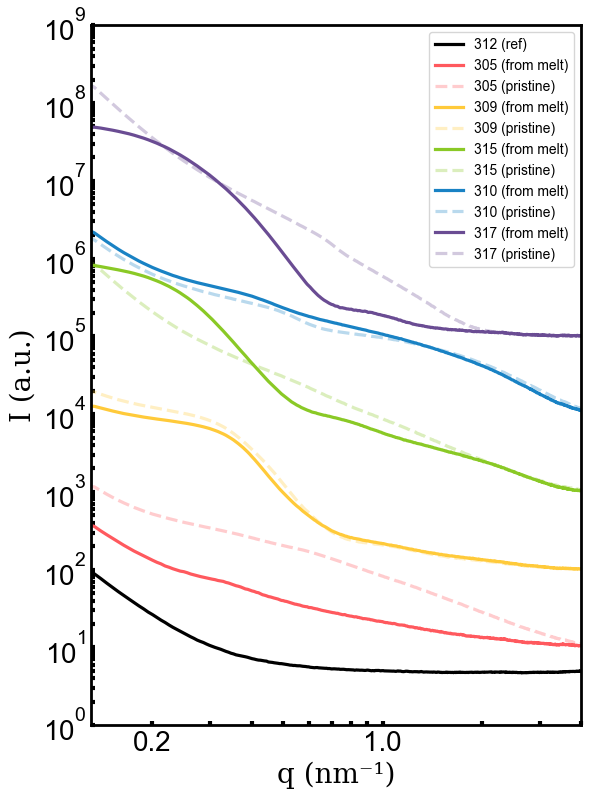

In [344]:
SAXS_plot(7,10)

k = 10

I = average(I_array_312, [i for i in range(-10, 0, 1)]) 
I /= np.mean(I[(q > 4) * (q < 5)])
plt.plot(q, I * 5, linewidth=2.3, color='black', label='312 (ref)' )

# 305
I = average(I_array_305, [i for i in range(-10, 0, 1)]) 
I /= np.mean(I[(q > 4) * (q < 5)])
plt.plot(q, I * k ** 1, linewidth=2.3, color='#ff595e', label='305 (from melt)')

I = average(I_array_305, [i for i in range(0, 10, 1)]) 
I /= np.mean(I[(q > 4) * (q < 5)])
plt.plot(q, I * k ** 1, linewidth=2.3, color='#ff595e', label='305 (pristine)', alpha=0.3, linestyle='--')

# 309
I = average(I_array_309, [i for i in range(-10, 0, 1)]) 
I /= np.mean(I[(q > 4) * (q < 5)])
plt.plot(q, I * k ** 2, linewidth=2.3, color='#ffca3a', label='309 (from melt)')

I = average(I_array_309, [i for i in range(0, 10, 1)]) 
I /= np.mean(I[(q > 4) * (q < 5)])
plt.plot(q, I * k ** 2, linewidth=2.3, color='#ffca3a', label='309 (pristine)', alpha=0.3, linestyle='--')

# 315
I = average(I_array_315, [i for i in range(-10, 0, 1)]) 
I /= np.mean(I[(q > 4) * (q < 5)])
plt.plot(q,I * k ** 3, linewidth=2.3, color='#8ac926', label='315 (from melt)')

I = average(I_array_315, [i for i in range(0, 10, 1)]) 
I /= np.mean(I[(q > 4) * (q < 5)])
plt.plot(q, I * k ** 3, linewidth=2.3, color='#8ac926', label='315 (pristine)', alpha=0.3, linestyle='--')

# 310
I = average(I_array_310, [i for i in range(-10, 0, 1)]) 
I /= np.mean(I[(q > 4) * (q < 5)])
plt.plot(q, I * k ** 4 , linewidth=2.3, color='#1982c4', label='310 (from melt)')

I = average(I_array_310, [i for i in range(0, 10, 1)]) 
I /= np.mean(I[(q > 4) * (q < 5)])
plt.plot(q, I * k ** 4, linewidth=2.3, color='#1982c4', label='310 (pristine)', alpha=0.3, linestyle='--')

# 317
I = average(I_array_317, [i for i in range(-10, 0, 1)]) 
I /= np.mean(I[(q > 4) * (q < 5)])
plt.plot(q, I * k ** 5 , linewidth=2.3, color='#6a4c93', label='317 (from melt)')

I = average(I_array_317, [i for i in range(0, 10, 1)]) 
I /= np.mean(I[(q > 4) * (q < 5)])
plt.plot(q, I * k ** 5, linewidth=2.3, color='#6a4c93', label='317 (pristine)', alpha=0.3, linestyle='--')

plt.legend(fontsize=10, loc=1)
plt.xlim(0.13, 4)
plt.ylim(1e0, 1e9)

plt.savefig(r'C:\Users\LabPCA\Desktop\PEG_PLA\Nikos_312_317.png', dpi=300, bbox_inches='tight', transparent=True)

### swelling

In [385]:
path = r'E:\PEG_g_PLA Nikos 2025\SC5732\PLLA_brushes_swelling\PLLA_brushes_swelling_PA310_swelling'
Exp = BM26_experiment(path)

q, I_array = Exp.integrate1d_SAXS(ai, 1000, mask=img_mask, unit='q_nm^-1')


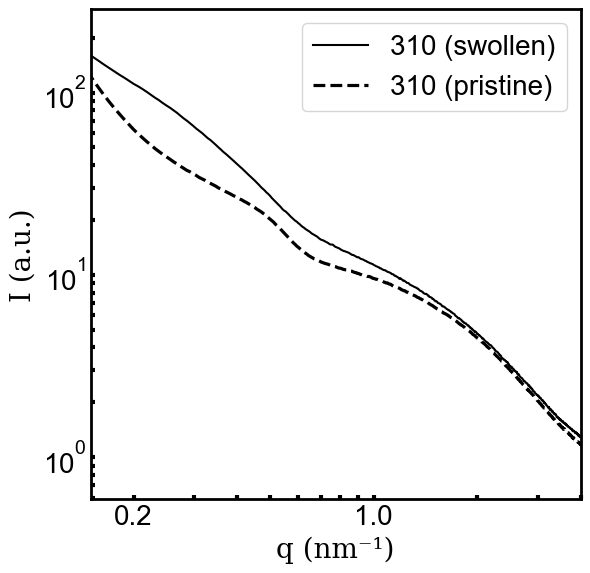

In [386]:
SAXS_plot(7,7)

plt.plot(q, I_array[0] / 1e1, color='blacK', label='310 (swollen)' )

plt.xlim(0.15, 4)

I = average(I_array_310, [i for i in range(0, 10, 1)]) 
I /= np.mean(I[(q > 4) * (q < 5)])
plt.plot(q, I, linewidth=2.3, color='blacK', label='310 (pristine)', alpha=1, linestyle='--')


plt.legend(fontsize=20, loc=1)
# plt.text(0.9, 0.9, 'swelling in PLA precense',  )
plt.savefig(r'C:\Users\LabPCA\Desktop\PEG_PLA\Nikos_PLA_swelling.png', dpi=300, bbox_inches='tight', transparent=True)

In [387]:
path = r'E:\PEG_g_PLA Nikos 2025\SC5732\PLLA_brushes_swelling\PLLA_brushes_swelling_PA312_drying'
Exp = BM26_experiment(path)

q, I_array = Exp.integrate1d_SAXS(ai, 1000, mask=img_mask, unit='q_nm^-1')

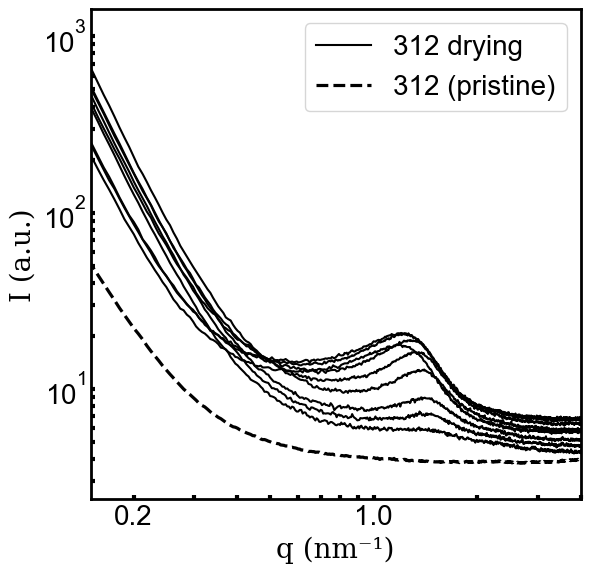

In [388]:
SAXS_plot(7,7)

plt.plot(q, I_array[0], color='blacK', label='312 drying' )
plt.plot(q, I_array[5], color='blacK', )
plt.plot(q, I_array[10], color='blacK', )
# plt.plot(q, I_array[15], color='blacK',  )
plt.plot(q, I_array[20], color='blacK',  )
plt.plot(q, I_array[25], color='blacK' )
plt.plot(q, I_array[30], color='blacK' )
plt.plot(q, I_array[35], color='blacK' )
plt.plot(q, I_array[39], color='blacK' )
plt.plot(q, I_array[43], color='blacK' )

plt.xlim(0.15, 4)

I = average(I_array_312, [i for i in range(0, 10, 1)]) 
I /= np.mean(I[(q > 4) * (q < 5)])
plt.plot(q, I * 4, linewidth=2.3, color='black', label='312 (pristine)', alpha=1, linestyle='--')


plt.legend(fontsize=20, loc=1)
# # plt.text(0.9, 0.9, 'swelling in PLA precense',  )
plt.savefig(r'C:\Users\LabPCA\Desktop\PEG_PLA\Nikos_PLA_drying.png', dpi=300, bbox_inches='tight', transparent=True)

### q_min

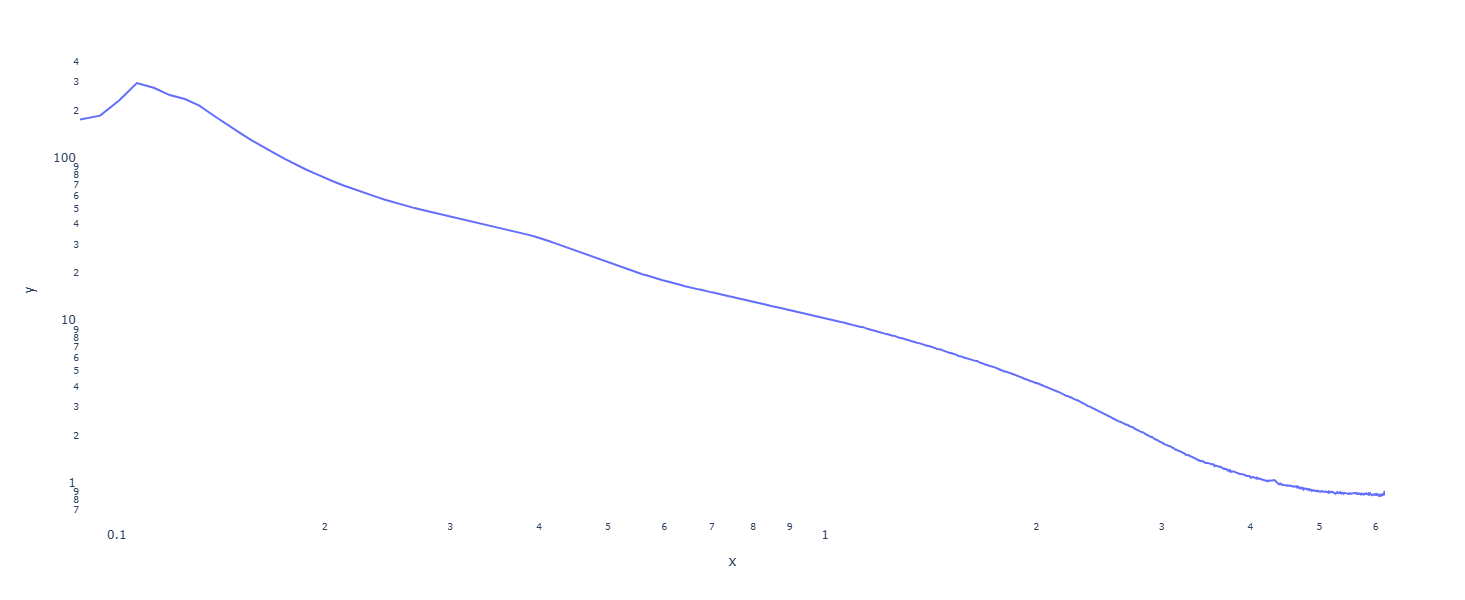

In [402]:
I = average(I_array_310, [i for i in range(-10, 0, 1)]) 
I /= np.mean(I[(q > 4) * (q < 5)])


fig = px.line(x=q, y=I, log_x=True, log_y=True)
fig.update_layout(width=600, height=600, plot_bgcolor='white')
fig.show()

In [411]:
(4 / 1.5) ** 2

7.111111111111111

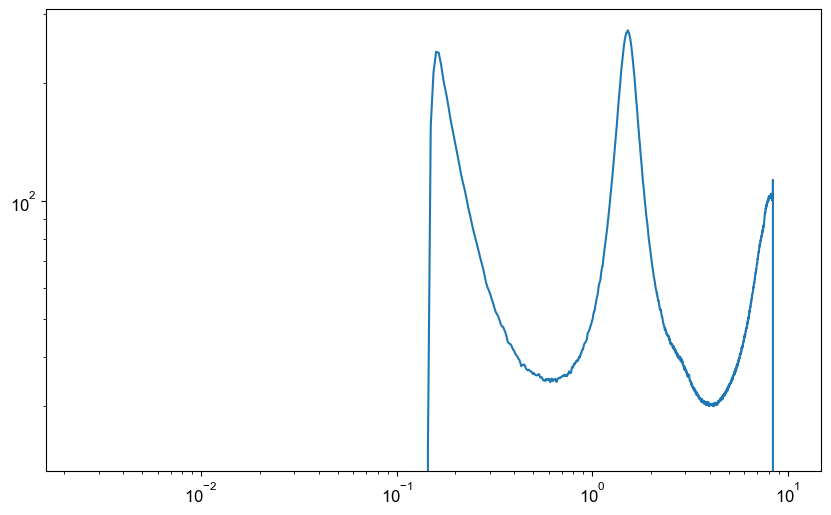

In [436]:
path = r"\\Synology\Data\2025\SC5711\Bottlebrushes\Bottlebrushes_EM_Chiral_N2_Melt_10202025_Heat90C"

Exp = BM26_experiment(path)

q, I = Exp.get_1d_SAXS(113) #average_1d([0,1,2,3])
plt.loglog(q, I)

Text(0, 0.5, 'I (a. u.)')

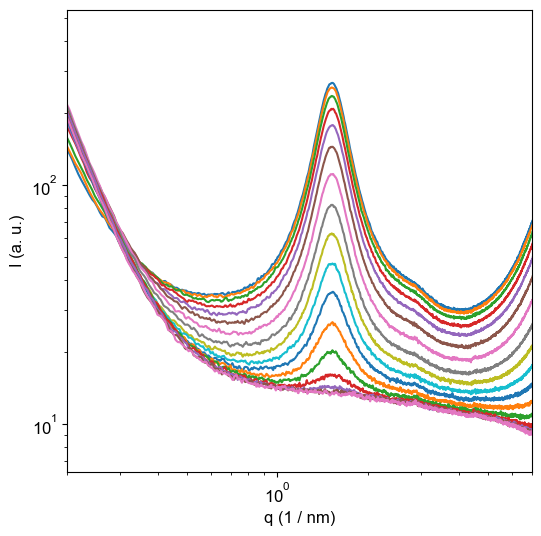

In [446]:
plt.figure(figsize=(6,6))
for i in range(114, 131):
    q, I = Exp.get_1d_SAXS(i)
    plt.loglog(q, I, label=f'T = {T[i]}')
plt.xlim(0.2, 7)
plt.xlabel('q (1 / nm)')
plt.ylabel('I (a. u.)')
# plt.legend()

Found 136 EDF files in SAXS


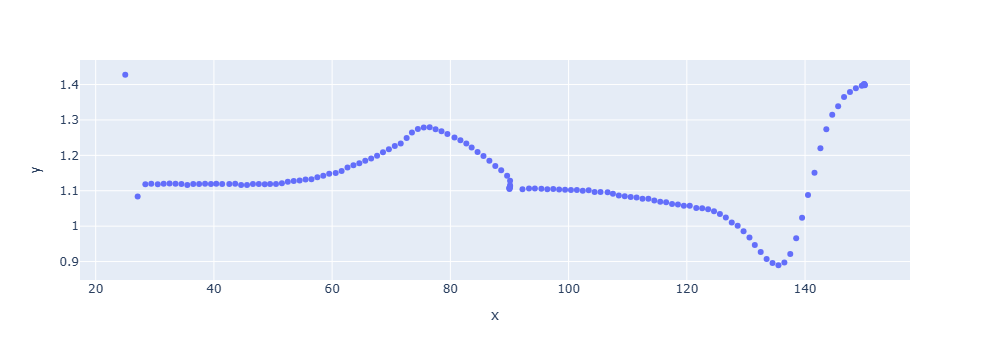

In [433]:
Tr = Exp.get_Tr_profile()
T = Exp.get_T_profile()
px.scatter(x=T, y = Tr)

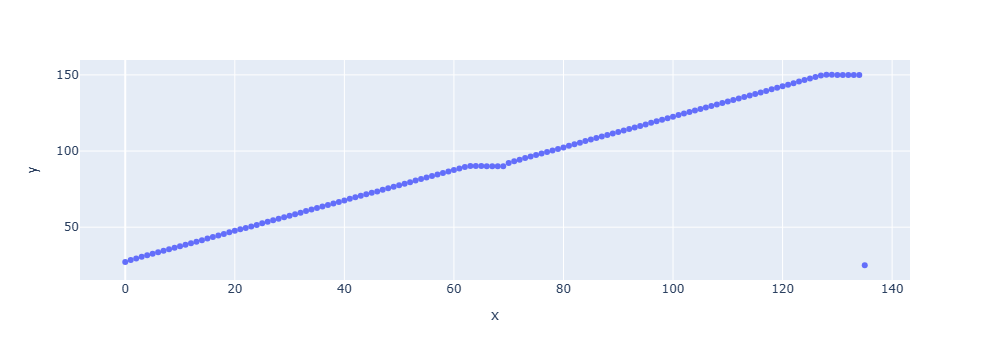

In [435]:
px.scatter(x=range(len(T)), y = T)

In [421]:
pd.DataFrame({'q':q, 'I':I}).to_csv(r'E:\OH_PDMS\chiral.txt', index=False, sep=str('\t'))